### 📊 AED para explorar o Engajamento das Atividades (IEG)

**Base:** `df_base.parquet` — consolidação gerada no Notebook `01_AED_DF_PROCESSED.ipynb`.

**❓Pergunta chave:**
- O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?

**Sub-perguntas:**
- Qual a distribuição do engajamento por ano e nível?
- Existem alunos com alto engajamento mas baixo desempenho (e vice-versa)?
- Quantos alunos estão "desengajados" (IEG muito baixo)?

#### ⚙️ Import e Setup

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

# Carregar base consolidada
df = pd.read_parquet('../data/processed/df_base.parquet')

# Confirmar se bate com os resultados obtidos durante a etapa de preparação no notebook 01_AED_DF_PROCESSED.ipynb
print(f'df_base: {df.shape[0]} linhas | {df.shape[1]} colunas')
print(f'Anos: {sorted(df["ano"].unique())}')
print(f'Registros por ano: {df["ano"].value_counts().sort_index().to_dict()}')

df_base: 3030 linhas | 31 colunas
Anos: [np.int64(2022), np.int64(2023), np.int64(2024)]
Registros por ano: {2022: 860, 2023: 1014, 2024: 1156}


### 📊 Geração de plots e insights

#### Distribuição do IEG por ano

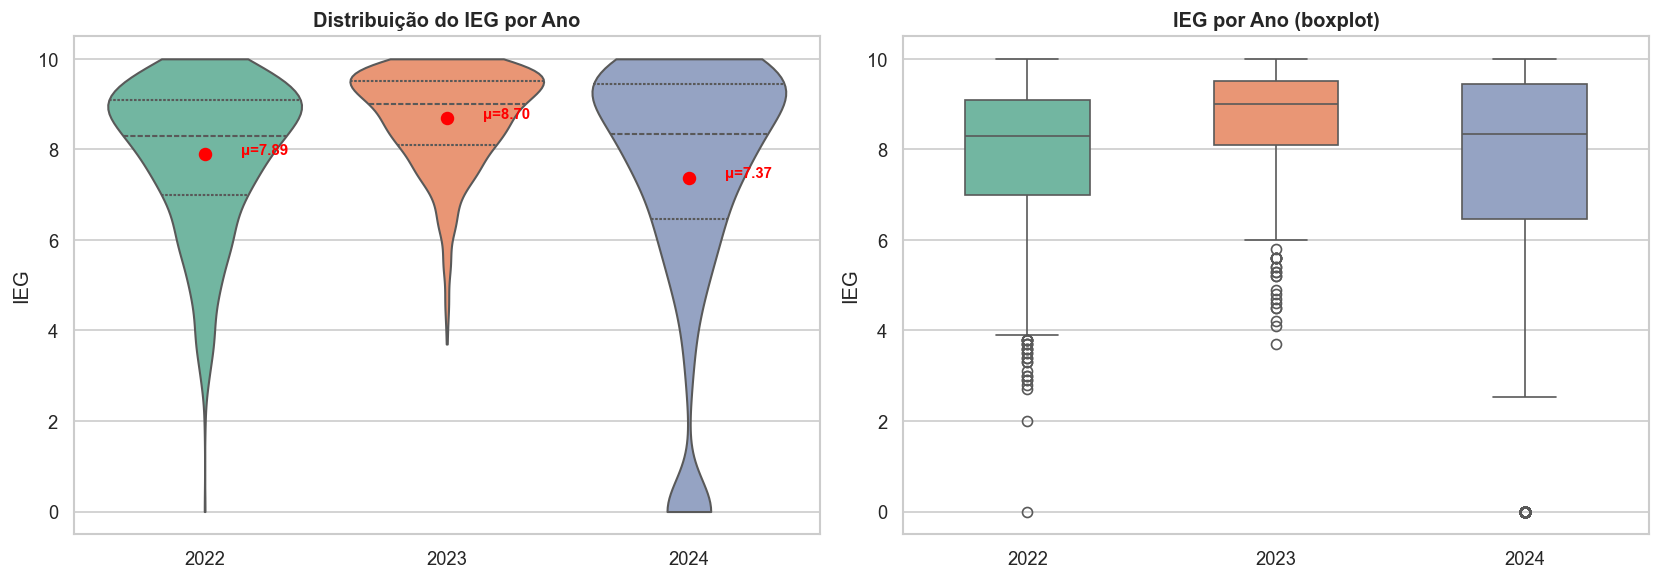

=== IEG — Estatísticas por ano ===
       count  mean   std  min   25%   50%   75%   max
ano                                                  
2022   860.0  7.89  1.64  0.0  7.00  8.30  9.10  10.0
2023   938.0  8.70  1.08  3.7  8.10  9.00  9.50  10.0
2024  1156.0  7.37  2.85  0.0  6.46  8.33  9.44  10.0


In [62]:
def distribuicao_ieg_por_ano(df):

    # Distribuição do IEG por ano
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    dados_violin = df[df['IEG'].notna()].copy()
    dados_violin['ano'] = dados_violin['ano'].astype(str)

    sns.violinplot(data=dados_violin, x='ano', y='IEG', ax=axes[0],
                palette='Set2', inner='quartile', cut=0)

    medias = dados_violin.groupby('ano')['IEG'].mean()
    for i, (ano, media) in enumerate(medias.items()):
        axes[0].scatter(i, media, color='red', s=50, zorder=5)
        axes[0].text(i + 0.15, media, f'μ={media:.2f}', fontsize=9, fontweight='bold', color='red')

    axes[0].set_title('Distribuição do IEG por Ano', fontweight='bold')
    axes[0].set_xlabel('')
    axes[0].set_ylabel('IEG')

    sns.boxplot(data=dados_violin, x='ano', y='IEG', ax=axes[1], palette='Set2', width=0.5)
    axes[1].set_title('IEG por Ano (boxplot)', fontweight='bold')
    axes[1].set_xlabel('')
    axes[1].set_ylabel('IEG')

    plt.tight_layout()
    plt.show()

    print('=== IEG — Estatísticas por ano ===')
    print(df.groupby('ano')['IEG'].describe().round(2).to_string())

distribuicao_ieg_por_ano(df)

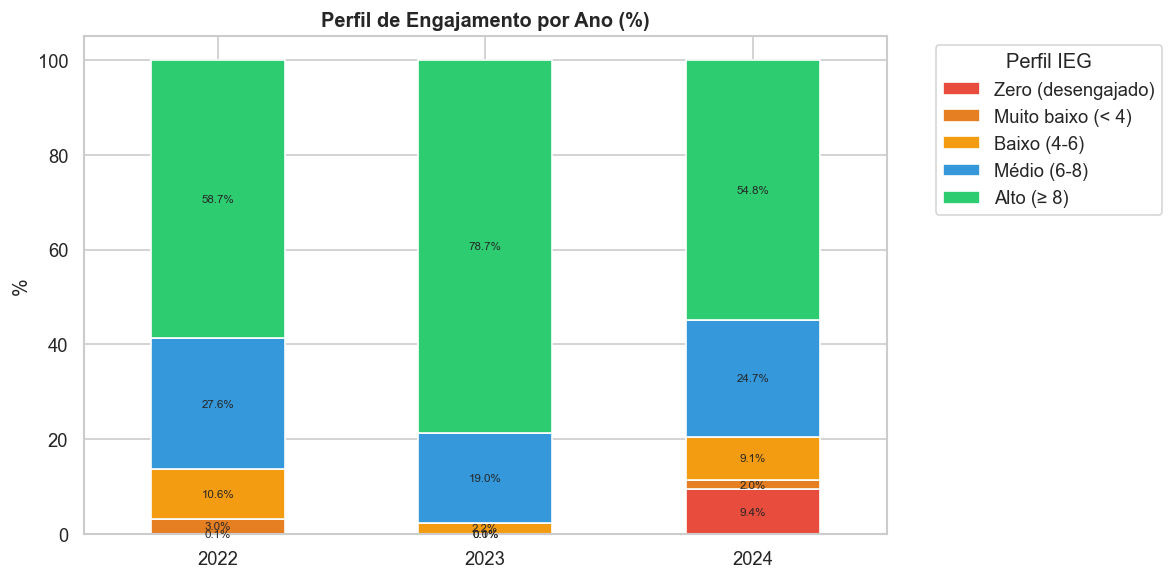

=== Perfil de engajamento por ano (absoluto) ===
perfil_ieg  Zero (desengajado)  Muito baixo (< 4)  Baixo (4-6)  Médio (6-8)  Alto (≥ 8)
ano                                                                                    
2022                         1                 26           91          237         505
2023                         0                  1           21          178         738
2024                       109                 23          105          285         634


In [63]:
def perfil_engajamento(df):

    # Identificar perfis de engajamento
    df_eng = df[df['IEG'].notna()].copy()

    def classificar_engajamento(ieg):
        if ieg == 0: return 'Zero (desengajado)'
        if ieg < 4: return 'Muito baixo (< 4)'
        if ieg < 6: return 'Baixo (4-6)'
        if ieg < 8: return 'Médio (6-8)'
        return 'Alto (≥ 8)'

    df_eng['perfil_ieg'] = df_eng['IEG'].apply(classificar_engajamento)

    ordem = ['Zero (desengajado)', 'Muito baixo (< 4)', 'Baixo (4-6)', 'Médio (6-8)', 'Alto (≥ 8)']
    cores = {'Zero (desengajado)': '#e74c3c', 'Muito baixo (< 4)': '#e67e22',
            'Baixo (4-6)': '#f39c12', 'Médio (6-8)': '#3498db', 'Alto (≥ 8)': '#2ecc71'}

    ct = pd.crosstab(df_eng['ano'], df_eng['perfil_ieg'])[ordem]
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    fig, ax = plt.subplots(figsize=(10, 5))
    ct_pct.plot(kind='bar', stacked=True, ax=ax, color=[cores[c] for c in ordem])
    ax.set_title('Perfil de Engajamento por Ano (%)', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('%')
    ax.legend(title='Perfil IEG', bbox_to_anchor=(1.05, 1))
    ax.tick_params(axis='x', rotation=0)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=7)

    plt.tight_layout()
    plt.show()

    print('=== Perfil de engajamento por ano (absoluto) ===')
    print(ct.to_string())

perfil_engajamento(df)

##### 💡 Insight

- **109 alunos com IEG=0** em 2024 é muito alto e fora da curva
  - Será que isso está certo? Erro nos dados? Mudança na forma de salvar os dados? Vamos validar abaixo

In [64]:
# Comparar: em 2022 e 2023, os alunos sem avaliação completa tinham IEG=NaN ou IEG=0?
print('=== IEG: zeros vs nulos por ano ===')
for ano in [2022, 2023, 2024]:
    sub = df[df['ano'] == ano]
    zeros = (sub['IEG'] == 0).sum()
    nulos = sub['IEG'].isna().sum()
    total = len(sub)
    print(f'  {ano}: zeros={zeros}, nulos={nulos}, total={total}')

# Mesma verificação para IDA (que tem padrão similar)
print('\n=== IDA: zeros vs nulos por ano ===')
for ano in [2022, 2023, 2024]:
    sub = df[df['ano'] == ano]
    zeros = (sub['IDA'] == 0).sum()
    nulos = sub['IDA'].isna().sum()
    total = len(sub)
    print(f'  {ano}: zeros={zeros}, nulos={nulos}, total={total}')

# Cruzar: os 109 com IEG=0 em 2024 também têm outros indicadores zerados?
df_zero_2024 = df[(df['ano'] == 2024) & (df['IEG'] == 0)]
indicadores = ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV']
print('\n=== Dos 109 com IEG=0 em 2024: outros indicadores ===')
for ind in indicadores:
    zeros = (df_zero_2024[ind] == 0).sum()
    nulos = df_zero_2024[ind].isna().sum()
    print(f'  {ind}: zeros={zeros}, nulos={nulos}')

=== IEG: zeros vs nulos por ano ===
  2022: zeros=1, nulos=0, total=860
  2023: zeros=0, nulos=76, total=1014
  2024: zeros=109, nulos=0, total=1156

=== IDA: zeros vs nulos por ano ===
  2022: zeros=6, nulos=0, total=860
  2023: zeros=1, nulos=77, total=1014
  2024: zeros=16, nulos=101, total=1156

=== Dos 109 com IEG=0 em 2024: outros indicadores ===
  IDA: zeros=7, nulos=101
  IEG: zeros=109, nulos=0
  IAA: zeros=0, nulos=102
  IPS: zeros=0, nulos=102
  IPP: zeros=0, nulos=102
  IPV: zeros=0, nulos=102


#### ⚠️ Alerta!!!

- Achamos algo interessante... houve uma "mudança" na forma em que os dados eram salvos no banco de dados 2022/2023 x 2024
- Antes, alunos sem avaliação tinham IEG = NaN, porém a partir de 2024, isso está sendo representado como IEG = 0
  - Isso afeta o cálculo da média, que ignora NaN
- Logo, não temos 109 desengajados em 2024, mas 8 (IEG=0 com IDA preenchido)
- E é possível que o mesmo esteja acontecendo com o IDA...

#### Correção do dataframe

In [65]:
# Correção: IEG=0 e IDA=0 em 2024 onde o aluno não foi avaliado → NaN
# O padrão de codificação mudou entre 2023 (NaN) e 2024 (0) para alunos não avaliados
# Critério: se IAA é nulo, o aluno não foi avaliado — zeros são falsos

mask_nao_avaliado = (df['ano'] == 2024) & (df['IAA'].isna())

for col in ['IEG', 'IDA']:
    mask = mask_nao_avaliado & (df[col] == 0)
    n = mask.sum()
    df.loc[mask, col] = np.nan
    print(f'{col} corrigidos de 0 → NaN: {n}')

print(f'\n=== Verificação pós-correção: zeros vs nulos ===')
for col in ['IEG', 'IDA']:
    print(f'\n  {col}:')
    for ano in [2022, 2023, 2024]:
        sub = df[df['ano'] == ano]
        zeros = (sub[col] == 0).sum()
        nulos = sub[col].isna().sum()
        print(f'    {ano}: zeros={zeros}, nulos={nulos}')

IEG corrigidos de 0 → NaN: 102
IDA corrigidos de 0 → NaN: 0

=== Verificação pós-correção: zeros vs nulos ===

  IEG:
    2022: zeros=1, nulos=0
    2023: zeros=0, nulos=76
    2024: zeros=7, nulos=102

  IDA:
    2022: zeros=6, nulos=0
    2023: zeros=1, nulos=77
    2024: zeros=16, nulos=101


In [66]:
# Verificar os 16 com IDA=0 em 2024: foram avaliados ou não?
df_ida_zero_2024 = df[(df['ano'] == 2024) & (df['IDA'] == 0)]

print(f'16 alunos com IDA=0 em 2024:')
print(f'  IAA nulo: {df_ida_zero_2024["IAA"].isna().sum()}')
print(f'  IAA preenchido: {df_ida_zero_2024["IAA"].notna().sum()}')
print(f'  IEG nulo: {df_ida_zero_2024["IEG"].isna().sum()}')
print(f'  IEG preenchido: {df_ida_zero_2024["IEG"].notna().sum()}')

16 alunos com IDA=0 em 2024:
  IAA nulo: 0
  IAA preenchido: 16
  IEG nulo: 0
  IEG preenchido: 16


##### 💡 Insights

- Os 16 alunos com IDA=0 são zeros reais, já que os alunos foram avaliados (IAA e IEG preenchidos), mas tiraram zero em desempenho acadêmico

#### Rodar novamente Distribuição do IEG por ano (com novo DF)

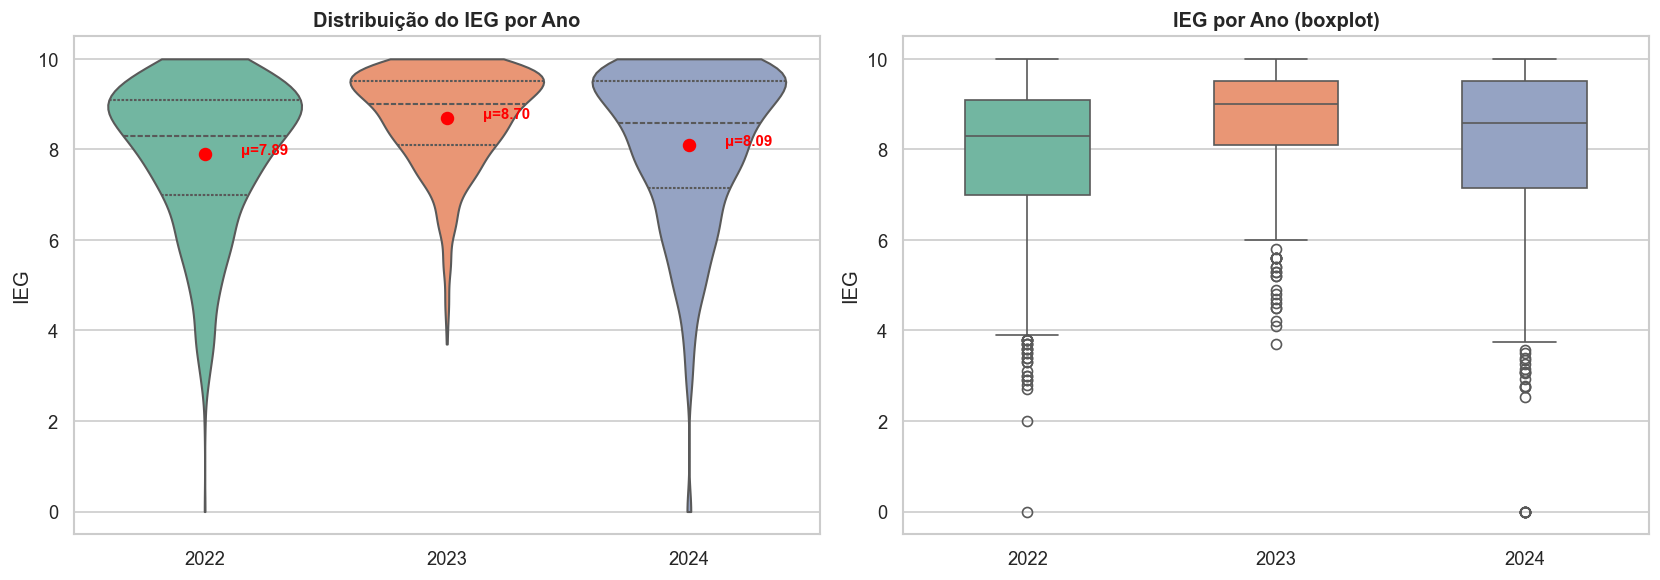

=== IEG — Estatísticas por ano ===
       count  mean   std  min   25%   50%  75%   max
ano                                                 
2022   860.0  7.89  1.64  0.0  7.00  8.30  9.1  10.0
2023   938.0  8.70  1.08  3.7  8.10  9.00  9.5  10.0
2024  1054.0  8.09  1.76  0.0  7.15  8.59  9.5  10.0


In [67]:
distribuicao_ieg_por_ano(df)

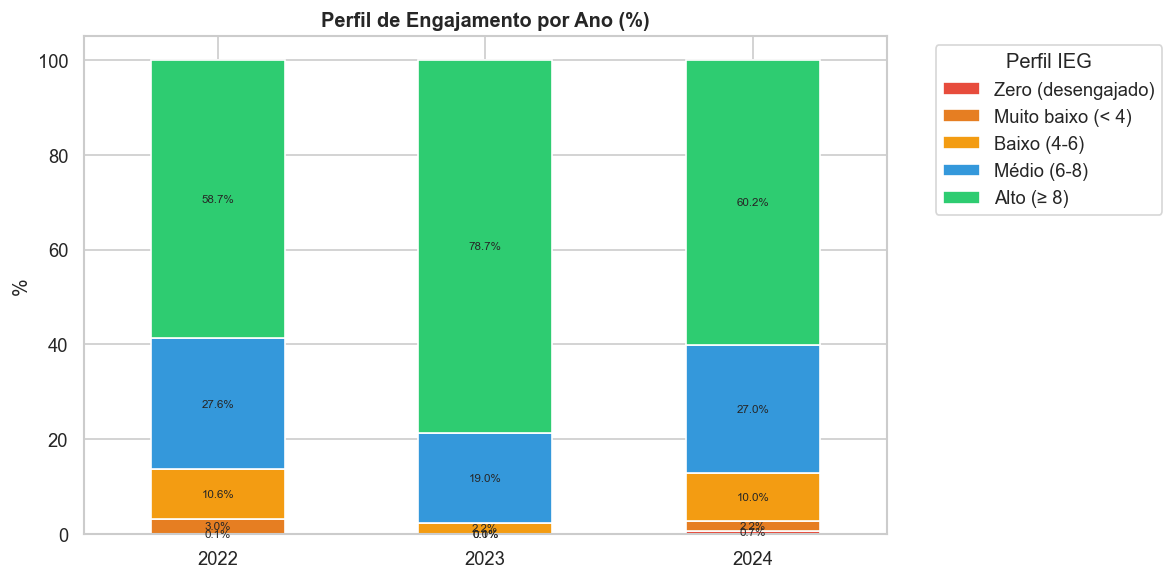

=== Perfil de engajamento por ano (absoluto) ===
perfil_ieg  Zero (desengajado)  Muito baixo (< 4)  Baixo (4-6)  Médio (6-8)  Alto (≥ 8)
ano                                                                                    
2022                         1                 26           91          237         505
2023                         0                  1           21          178         738
2024                         7                 23          105          285         634


In [68]:
perfil_engajamento(df)

##### 💡 Insights atualizados

- O engajamento médio está alto e estável: 7.89 -> 8.70 -> 8.09
- A maioria dos alunos tem IEG ≥ 8 (alto) nos 3 anos: 58.7% → 78.7% → 60.2%
- O desengajamento real (IEG=0) é raro: 1, 0 e 7 alunos nos 3 anos
- - 2023 continua com a média mais alta, mas é inflado pelo viés de avaliação incompleta já identificado no `02_AED_IDA.ipynb`

#### Existem alunos com alto engajamento mas baixo desempenho (e vice-versa)?

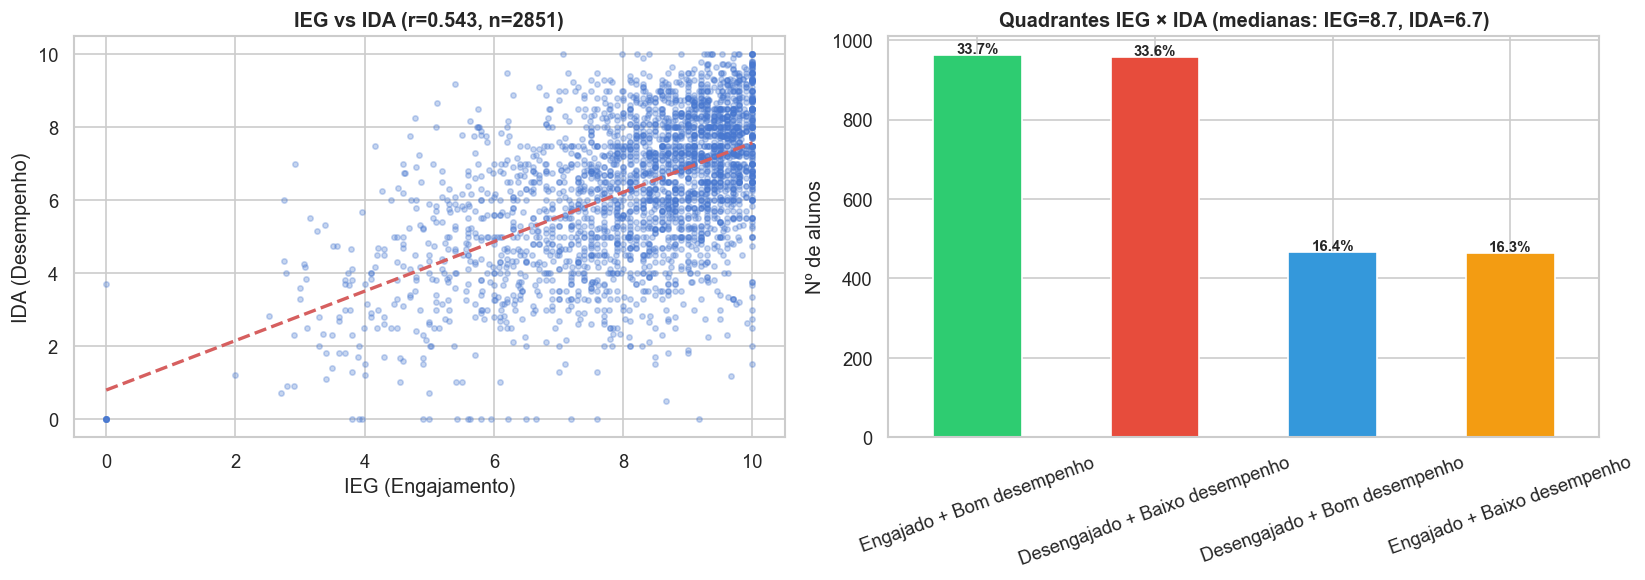

In [69]:
# Relação IEG × IDA
df_ieg_ida = df[df['IEG'].notna() & df['IDA'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter com correlação
axes[0].scatter(df_ieg_ida['IEG'], df_ieg_ida['IDA'], alpha=0.3, s=10)
corr = df_ieg_ida['IEG'].corr(df_ieg_ida['IDA'])
z = np.polyfit(df_ieg_ida['IEG'], df_ieg_ida['IDA'], 1)
p = np.poly1d(z)
x_range = np.linspace(0, 10, 100)
axes[0].plot(x_range, p(x_range), 'r--', linewidth=2)
axes[0].set_title(f'IEG vs IDA (r={corr:.3f}, n={len(df_ieg_ida)})', fontweight='bold')
axes[0].set_xlabel('IEG (Engajamento)')
axes[0].set_ylabel('IDA (Desempenho)')

# Perfis cruzados: quadrantes
mediana_ieg = df_ieg_ida['IEG'].median()
mediana_ida = df_ieg_ida['IDA'].median()

def quadrante(row):
    if row['IEG'] >= mediana_ieg and row['IDA'] >= mediana_ida:
        return 'Engajado + Bom desempenho'
    if row['IEG'] >= mediana_ieg and row['IDA'] < mediana_ida:
        return 'Engajado + Baixo desempenho'
    if row['IEG'] < mediana_ieg and row['IDA'] >= mediana_ida:
        return 'Desengajado + Bom desempenho'
    return 'Desengajado + Baixo desempenho'

df_ieg_ida['quadrante'] = df_ieg_ida.apply(quadrante, axis=1)

quad_ct = df_ieg_ida['quadrante'].value_counts()
cores_quad = {
    'Engajado + Bom desempenho': '#2ecc71',
    'Engajado + Baixo desempenho': '#f39c12',
    'Desengajado + Bom desempenho': '#3498db',
    'Desengajado + Baixo desempenho': '#e74c3c'
}
quad_ct.plot(kind='bar', ax=axes[1], color=[cores_quad[q] for q in quad_ct.index])
axes[1].set_title(f'Quadrantes IEG × IDA (medianas: IEG={mediana_ieg:.1f}, IDA={mediana_ida:.1f})',
                   fontweight='bold')
axes[1].set_ylabel('Nº de alunos')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)

for i, (q, n) in enumerate(quad_ct.items()):
    axes[1].text(i, n + 5, f'{n/len(df_ieg_ida)*100:.1f}%', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

##### 💡 Insights

- O scatter plot mostra uma correlação moderada (0.543) entre o IEG e IDA
  - Ou seja, engajamento ajuda, mas não é garantia de bom desempenho

- Já no gráfico de barra nos mostra um balanceamento em 3 grupos:
  - Bom desempenho + Engajado (33.7%) - perfil ideal
  - Baixo desempenho + Desengajado (33.6%) - grupo de risco principal
  - Misto (32.7%)
    - Bom desempenho + Desengajado (16.4%) - possuem potencial, mas precisam de motivação
    - Baixo desempenho + Engajado (16.3%) - estão tentando, motivados, mas precisam de suporte pedagógico

**Insight criativo para a ONG:**
- intervenções diferentes para perfis diferentes — não basta olhar só a nota ou só o engajamento


#### Relação IEG × IPV

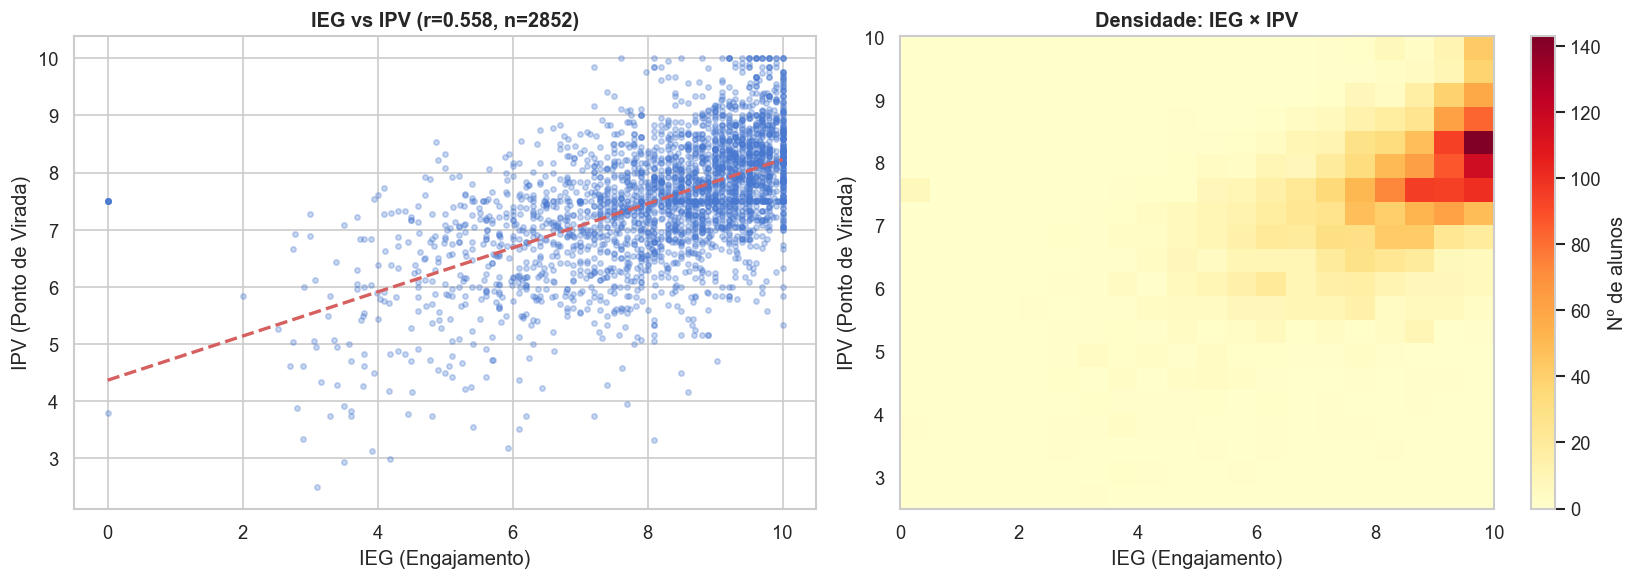


=== Correlações do IEG ===
  IEG × IDA: r=0.543
  IEG × IPV: r=0.558


In [70]:
# Heatmap de densidade IEG × IPV
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter com regressão
axes[0].scatter(df_ieg_ipv['IEG'], df_ieg_ipv['IPV'], alpha=0.3, s=10)
corr_ipv = df_ieg_ipv['IEG'].corr(df_ieg_ipv['IPV'])
z = np.polyfit(df_ieg_ipv['IEG'], df_ieg_ipv['IPV'], 1)
p = np.poly1d(z)
x_range = np.linspace(df_ieg_ipv['IEG'].min(), df_ieg_ipv['IEG'].max(), 100)
axes[0].plot(x_range, p(x_range), 'r--', linewidth=2)
axes[0].set_title(f'IEG vs IPV (r={corr_ipv:.3f}, n={len(df_ieg_ipv)})', fontweight='bold')
axes[0].set_xlabel('IEG (Engajamento)')
axes[0].set_ylabel('IPV (Ponto de Virada)')

# Heatmap de densidade — mostra onde os alunos se concentram
h = axes[1].hist2d(df_ieg_ipv['IEG'], df_ieg_ipv['IPV'], bins=20, cmap='YlOrRd')
plt.colorbar(h[3], ax=axes[1], label='Nº de alunos')
axes[1].set_title('Densidade: IEG × IPV', fontweight='bold')
axes[1].set_xlabel('IEG (Engajamento)')
axes[1].set_ylabel('IPV (Ponto de Virada)')

plt.tight_layout()
plt.show()

# Correlações resumo
print(f'\n=== Correlações do IEG ===')
print(f'  IEG × IDA: r={corr:.3f}')
print(f'  IEG × IPV: r={corr_ipv:.3f}')

##### 💡 Insights

- Correlação moderada (r=0.558): similar à relação IEG × IDA
- O heatmap de densidade confirma: a maior concentração de alunos está na zona IEG 9-10 e IPV 7-8 (140+ alunos)
- Engajamento alto é quase pré-requisito para IPV alto — o canto "baixo IEG + alto IPV" está vazio
- Porém, IEG alto não garante IPV máximo: mesmo com IEG 9-10, o IPV varia entre 6 e 10


### ⭐️ Insight Final — Pilar 3 (IEG)

#### O grau de engajamento (IEG) tem relação direta com o desempenho (IDA) e o ponto de virada (IPV)?

**Sim, existe relação direta (mas moderada, não determinística)**
- IEG × IDA: r=0.543 — engajamento e desempenho caminham juntos, mas não são a mesma coisa
- IEG × IPV: r=0.558 — engajamento e ponto de virada têm relação de força similar

**Perfil de engajamento:**
- O engajamento geral é alto e estável ao longo dos anos (média entre 7.89 e 8.70)
- O desengajamento real (IEG=0) é raro: apenas 1, 0 e 7 alunos nos 3 anos
- ⚠️ Descoberta importante: 102 registros com IEG=0 em 2024 eram falsos zeros — mudança de codificação de NaN=>0 para alunos não avaliados

**Quatro perfis de aluno identificados (quadrantes IEG × IDA):**

- Bom desempenho + Engajado (33.7%) - perfil ideal
- Baixo desempenho + Desengajado (33.6%) - grupo de risco principal
- Misto (32.7%)
  - Bom desempenho + Desengajado (16.4%) - possuem potencial, mas precisam de motivação
  - Baixo desempenho + Engajado (16.3%) - estão tentando, motivados, mas precisam de suporte pedagógico

**Notas finais:**
- Para a ONG: intervenções diferenciadas por perfil — não basta olhar só nota ou só engajamento
- 🤖 **Para o modelo de ML:** IEG é um fator relevante mas não suficiente... possivelmente precisaremos combinr com outros indicadores
- Engajamento alto é quase pré-requisito para IPV alto, porém não garante IPV máximo

### 💾 Salvar novo DF como Parquet 

In [74]:
# Salvar df_base atualizado com a correção do IEG (falsos zeros → NaN)
df.to_parquet('../data/processed/df_base_3.parquet', index=False)

print(f'✅ df_base atualizado salvo')
print(f'   {df.shape[0]} linhas | {df.shape[1]} colunas')
print(f'\n=== Verificação: IEG zeros vs nulos ===')
for ano in [2022, 2023, 2024]:
    sub = df[df['ano'] == ano]
    zeros = (sub['IEG'] == 0).sum()
    nulos = sub['IEG'].isna().sum()
    print(f'  {ano}: zeros={zeros}, nulos={nulos}')

✅ df_base atualizado salvo
   3030 linhas | 31 colunas

=== Verificação: IEG zeros vs nulos ===
  2022: zeros=1, nulos=0
  2023: zeros=0, nulos=76
  2024: zeros=7, nulos=102
